# Two-Tower Recommender on MovieLens

Двухбашенная retrieval-модель с нуля: эмбеддинги юзера и фильма, близость = дот-продукт, обучение in-batch softmax.

## 0. Импорты и загрузка данных

In [68]:
import pandas as pd
import random
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
%matplotlib inline

In [69]:
import kagglehub
dataset_path = kagglehub.dataset_download('abhikjha/movielens-100k') + '/ml-latest-small'
print(dataset_path)

D:\kaggle_cache\datasets\abhikjha\movielens-100k\versions\1/ml-latest-small


## 1. Данные и разведка

MovieLens (ml-latest-small): 610 юзеров × 9724 фильма, разреженность ~1.7%.

In [70]:
movies = pd.read_csv(dataset_path + '/movies.csv')

In [71]:
ratings = pd.read_csv(dataset_path + '/ratings.csv')

In [72]:
ratings['userId'].value_counts()

userId
414    2698
599    2478
474    2108
448    1864
274    1346
       ... 
442      20
278      20
147      20
320      20
53       20
Name: count, Length: 610, dtype: int64

In [73]:
ratings['movieId'].value_counts()

movieId
356       329
318       317
296       307
593       279
2571      278
         ... 
160341      1
160527      1
160836      1
163937      1
135534      1
Name: count, Length: 9724, dtype: int64

In [74]:
user_count = len(ratings['userId'].drop_duplicates())

In [75]:
movie_count = len(ratings['movieId'].drop_duplicates())

In [76]:
ratings['rating'].value_counts()

rating
4.0    26818
3.0    20047
5.0    13211
3.5    13136
4.5     8551
2.0     7551
2.5     5550
1.0     2811
1.5     1791
0.5     1370
Name: count, dtype: int64

In [77]:
len(ratings)

100836

In [78]:
potential_ratings = user_count * movie_count
(len(ratings) / potential_ratings) * 100

1.6999683055613624

In [79]:
len(ratings[ratings['rating']>= 4.0])

48580

## 2. Постановка задачи

Позитивы = оценки ≥ 4.0. Негативы берём in-batch (непросмотренные фильмы других юзеров батча).

In [80]:
pos_ratings = ratings[ratings['rating']>= 4.0]

In [81]:
result = pd.merge(ratings, movies, on='movieId').drop(columns=['genres'])

In [82]:
pos_result = pd.merge(pos_ratings, movies, on='movieId').drop(columns=['genres'])

## 3. Перенумерация ID

Сырые userId/movieId → плотные индексы 0..N-1 для эмбеддинг-таблиц (как `stoi` в makemore).

In [83]:
userIds = result['userId'].drop_duplicates()
user2idx = {id: i for i, id in enumerate(userIds)}
movieIds = result['movieId'].drop_duplicates()
movie2idx = {id: i for i, id in enumerate(movieIds)}

In [84]:
result['userIdx'] = result['userId'].map(user2idx)
result['movieIdx'] = result['movieId'].map(movie2idx)

In [85]:
pos_result['userIdx'] = pos_result['userId'].map(user2idx)
pos_result['movieIdx'] = pos_result['movieId'].map(movie2idx)

## 4. Split по времени (leave-last-out)

Внутри каждого юзера: ранние оценки → train, поздние → test. По времени, а не случайно — чтобы не было утечки будущего.

In [86]:
pos_result = pos_result.sort_values(by=['userIdx', 'timestamp'], ascending=[True, True])

In [87]:
pos_result['row_num'] = pos_result.groupby('userIdx').cumcount()

In [88]:
user_sizes = pos_result.groupby('userIdx').size().reset_index(name='total_count')

In [89]:
pos_result = pd.merge(pos_result, user_sizes, on='userIdx')

In [90]:
pos_result['pct_position'] = pos_result['row_num'] / pos_result['total_count']

In [91]:
train = pos_result[pos_result['pct_position'] < 0.80].copy()
val = pos_result[(pos_result['pct_position'] >= 0.80) & (pos_result['pct_position'] < 0.90)].copy()
test = pos_result[pos_result['pct_position'] >= 0.90].copy()

In [92]:
columns_to_drop = ['row_num', 'total_count', 'pct_position']
train.drop(columns=columns_to_drop, inplace=True)
val.drop(columns=columns_to_drop, inplace=True)
test.drop(columns=columns_to_drop, inplace=True)

## 5. Модель — две башни

Две `nn.Embedding` таблицы (n_dim=32). score = (u · m) / √d.

In [93]:
n_embd_user = len(user2idx)
n_embd_movie = len(movie2idx)
n_dim = 32
g = torch.Generator().manual_seed(2147483647)

user_emb = nn.Embedding(n_embd_user, n_dim)
movie_emb = nn.Embedding(n_embd_movie, n_dim) 

## 6. Обучение (in-batch softmax)

scores = U @ Mᵀ, диагональ = позитивы, остальное = негативы. Loss = cross-entropy.

In [94]:
train_users  = torch.tensor(train['userIdx'].values)
train_movies = torch.tensor(train['movieIdx'].values)

In [95]:
LR = 1e-3
all_embeddings = list(user_emb.parameters()) + list(movie_emb.parameters())
optimizer = Adam(all_embeddings, lr=LR)

In [96]:
max_steps = 200000
batch_size = 256
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, train.shape[0], (batch_size,), generator=g)
    user_idx_b, movie_idx_b = train_users[ix], train_movies[ix]

    # forward pass
    uv = user_emb(user_idx_b)
    mv = movie_emb(movie_idx_b)
    scores = (uv @ mv.T) / math.sqrt(n_dim) 
    labels = torch.arange(batch_size)       
    loss = F.cross_entropy(scores, labels)
    # backward 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
        
    lossi.append(loss.log10().item())

      0/ 200000: 6.0873


  10000/ 200000: 4.5267


  20000/ 200000: 3.7695


  30000/ 200000: 3.5456


  40000/ 200000: 3.3662


...

 150000/ 200000: 3.1783


 160000/ 200000: 3.1491


 170000/ 200000: 3.4286


 180000/ 200000: 3.3072


 190000/ 200000: 3.0561


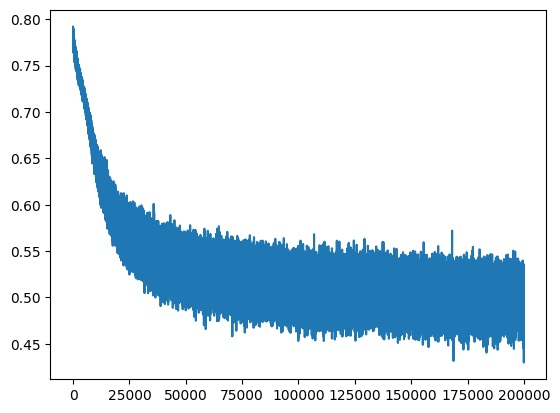

In [97]:
plt.plot(lossi)
plt.show()

## 7. Оценка — Recall@K

Тест-позитив ранжируется среди непросмотренных; доля попавших в топ-K. Baseline (случайно) ≈ 0.9%.

In [98]:
#Recall@K 
test_users = torch.tensor(test['userIdx'].drop_duplicates().tolist())
sum_of_recall = 0.0
with torch.no_grad():
    for user in test_users:
        print
        uv = user_emb(user)
        scores = uv @ movie_emb.weight.T
        scores[torch.tensor(train['movieIdx'][train['userIdx'] == user.item()].values)] = float('-inf')
        ranking = scores.argsort(descending=True) 
        
        test_movies = torch.tensor(test['movieIdx'][test['userIdx'] == user.item()].values)
        
        values, indices = torch.topk(scores, k=50)
        
        recall_k = len(set(indices.tolist()) & set(test_movies.tolist())) / len(test_movies)
        sum_of_recall += recall_k

recall = (sum_of_recall / len(test_users)) * 100
recall

14.197129635371136

## 8. Сохранение модели

Веса обеих башен + словари user2idx/movie2idx в одном чекпоинте.

In [ ]:
checkpoint = {
    'user_embeddings': user_emb.state_dict(),
    'movie_embeddings': movie_emb.state_dict(),
    'user2idx': user2idx,
    'movie2idx': movie2idx
}

In [ ]:
torch.save(checkpoint, 'model_and_dicts.pt')

In [ ]:
checkpoint = torch.load('model_and_dicts.pt')

user2idx = checkpoint['user2idx']
movie2idx = checkpoint['movie2idx']

n_embd_user = len(user2idx)
n_embd_movie = len(movie2idx)
n_dim = 32
g = torch.Generator().manual_seed(2147483647)

user_emb = nn.Embedding(n_embd_user, n_dim)
movie_emb = nn.Embedding(n_embd_movie, n_dim)

user_emb.load_state_dict(checkpoint['user_embeddings'])
movie_emb.load_state_dict(checkpoint['movie_embeddings'])


<All keys matched successfully>

<All keys matched successfully>